# Comparison of two group means

- Use Stan/cmdstanpy
- You are encouraged to use any AI agent, but you must understand the core idea of the python program provided by the agent.

1. Run the simulation experiment with N1 and N2 as written in the Exercise.
2. Change N1=300, N2=200, and run the same simulation experiment.
3. Compare the two results and provide your analysis and explanation.

![Exercise 4.5.1](./matsuura-exercise4.5.1.png)

In [3]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [4]:
# seed for reproducibility
np.random.seed(123)  # set.seed(123)
N1 = 30
mu1 = 0
sigma1 = 5
N2 = 20
mu2 = 1
sigma2 = 4
Y1 = np.random.normal(loc=mu1, scale=sigma1, size=N1) # Y1 ~ N(0, 5^2)
Y2 = np.random.normal(loc=mu2, scale=sigma2, size=N2) # Y2 ~ N(1, 4^2)

### (1) Visualize the data from the two groups

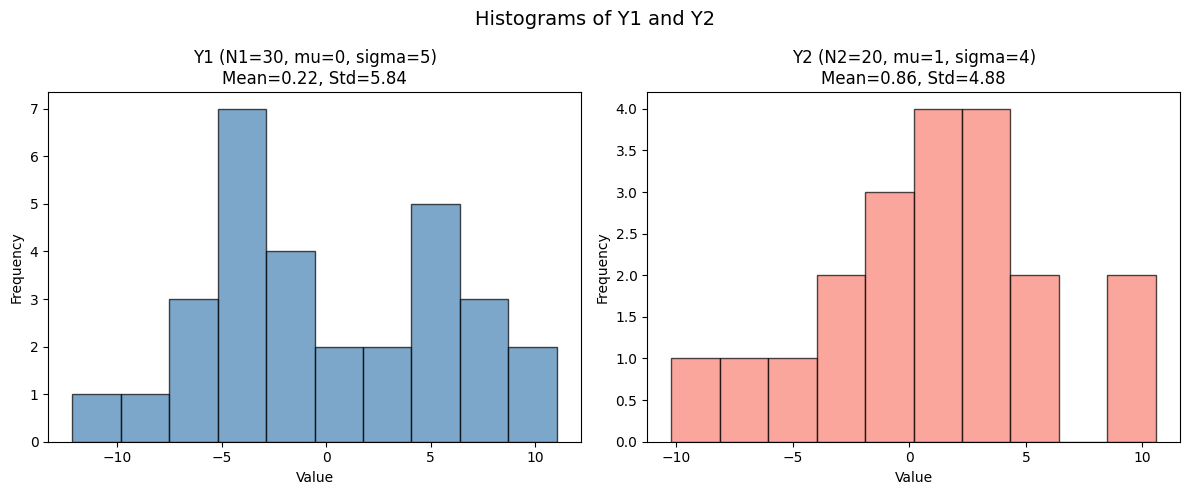

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(Y1, bins=10, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Y1 (N1={N1}, mu={mu1}, sigma={sigma1})\nMean={Y1.mean():.2f}, Std={Y1.std():.2f}')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(Y2, bins=10, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Y2 (N2={N2}, mu={mu2}, sigma={sigma2})\nMean={Y2.mean():.2f}, Std={Y2.std():.2f}')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')

plt.suptitle('Histograms of Y1 and Y2', fontsize=14)
plt.tight_layout()  
plt.show()      

### (2) Write a model formula with the assumption that these two groups have the same SD.
- This corresponds to the Student's t-test

Y1 ~ Normal(mu1, sigma)

Y2 ~ Normal(mu2, sigma)

In [6]:
stan_model_code = """
data {
    int<lower=0> N1;
    int<lower=0> N2;
    vector[N1] Y1;
    vector[N2] Y2;
}

parameters {
    real mu1;
    real mu2;
    real<lower=0> sigma;  // shared SD
}

model {
    // priors
    mu1 ~ normal(0, 100);
    mu2 ~ normal(0, 100);
    sigma ~ cauchy(0, 10);

    // likelihood
    Y1 ~ normal(mu1, sigma);
    Y2 ~ normal(mu2, sigma);
}

generated quantities {
    real diff = mu2 - mu1;  // difference of means
}
"""

# Save the model to a file
with open('compare_means_equal_std.stan', 'w') as f:
    f.write(stan_model_code)

print("Stan model saved to compare_means_equal_std.stan")
print(stan_model_code)

Stan model saved to compare_means_equal_std.stan

data {
    int<lower=0> N1;
    int<lower=0> N2;
    vector[N1] Y1;
    vector[N2] Y2;
}

parameters {
    real mu1;
    real mu2;
    real<lower=0> sigma;  // shared SD
}

model {
    // priors
    mu1 ~ normal(0, 100);
    mu2 ~ normal(0, 100);
    sigma ~ cauchy(0, 10);

    // likelihood
    Y1 ~ normal(mu1, sigma);
    Y2 ~ normal(mu2, sigma);
}

generated quantities {
    real diff = mu2 - mu1;  // difference of means
}



### (3) Estimate the parameters using 'cmdstanpy' using the Stan model code

In [7]:
from cmdstanpy import CmdStanModel

# 이 셀에 모델링과 추론 코드를 작성하세요.

# Build model from the Stan file created above
model_equal_sd = CmdStanModel(stan_file="compare_means_equal_std.stan")

# Data for Stan
stan_data = {
    "N1": N1,
    "N2": N2,
    "Y1": Y1,
    "Y2": Y2,
}

# MCMC sampling
fit_equal_sd = model_equal_sd.sample(
    data=stan_data,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=123
)

# Save draws for later cells
draws_equal_sd = fit_equal_sd.draws_pd(vars=["mu1", "mu2", "sigma", "diff"])

# Quick check
print(fit_equal_sd.summary().loc[["mu1", "mu2", "sigma", "diff"]])

13:37:54 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\Desktop\KOS-5101\homeworks\compare_means_equal_std.stan to exe file C:\Users\yongduek\Desktop\KOS-5101\homeworks\compare_means_equal_std.exe
13:38:18 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\Desktop\KOS-5101\homeworks\compare_means_equal_std.exe
13:38:18 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

13:38:18 - cmdstanpy - INFO - CmdStan done processing.
13:38:18 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'compare_means_equal_std.stan', line 22, column 4 to column 28)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'compare_means_equal_std.stan', line 22, column 4 to column 28)
Consider re-running with show_console=True if the above output is unclear!



           Mean      MCSE    StdDev       MAD       5%       50%      95%  \
mu1    0.211046  0.017432  1.051570  1.024890 -1.50812  0.208941  1.90251   
mu2    0.853347  0.020668  1.264800  1.252330 -1.21760  0.851427  2.94750   
sigma  5.715120  0.009945  0.602782  0.595597  4.83621  5.657340  6.77779   
diff   0.642301  0.025472  1.582650  1.546710 -1.97645  0.642989  3.20049   

       ESS_bulk  ESS_tail    R_hat  
mu1     3663.67   2833.96  1.00069  
mu2     3770.89   2919.45  1.00112  
sigma   3772.40   2823.58  1.00072  
diff    3936.02   2307.88  1.00019  


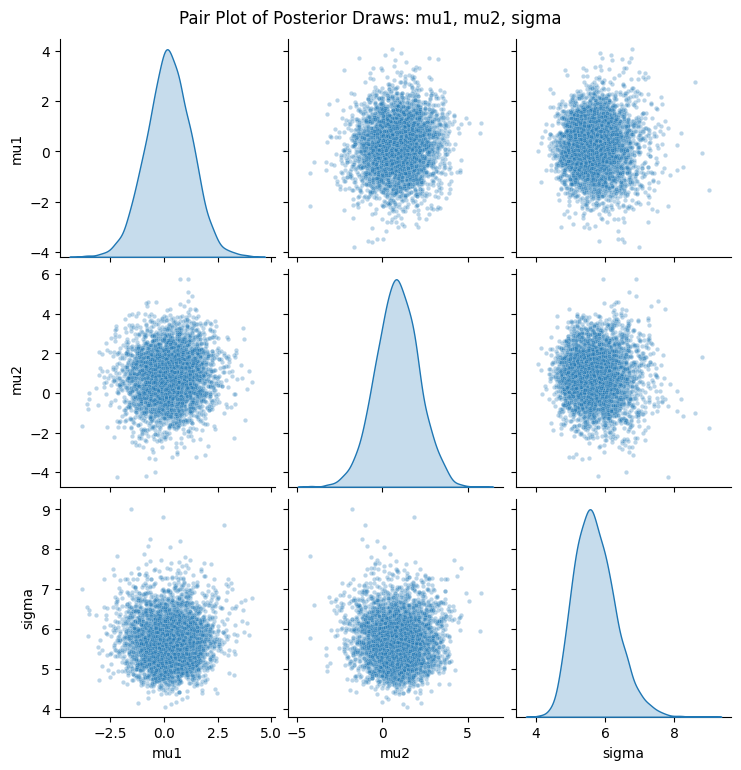

In [8]:
# 추론 결과를 그림으로 보여주세요.

pair_grid = sns.pairplot(
    draws_equal_sd[["mu1", "mu2", "sigma"]],
    kind="scatter",
    diag_kind="kde",
    plot_kws={"s": 10, "alpha": 0.3},
    diag_kws={"fill": True}
)
pair_grid.fig.suptitle("Pair Plot of Posterior Draws: mu1, mu2, sigma", y=1.02)
plt.show()

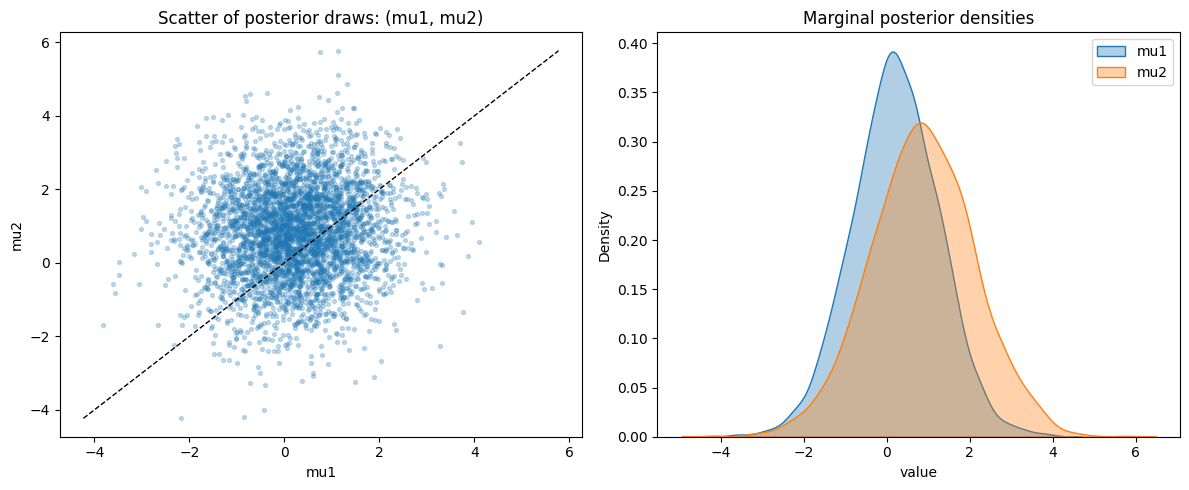

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (1) Joint scatter: (mu1, mu2)
axes[0].scatter(draws_equal_sd["mu1"], draws_equal_sd["mu2"], s=8, alpha=0.25, color="tab:blue")
mn = min(draws_equal_sd["mu1"].min(), draws_equal_sd["mu2"].min())
mx = max(draws_equal_sd["mu1"].max(), draws_equal_sd["mu2"].max())
axes[0].plot([mn, mx], [mn, mx], "k--", lw=1)
axes[0].set_xlabel("mu1")
axes[0].set_ylabel("mu2")
axes[0].set_title("Scatter of posterior draws: (mu1, mu2)")

# (2) Marginals of mu1 and mu2
sns.kdeplot(draws_equal_sd["mu1"], ax=axes[1], fill=True, alpha=0.35, color="tab:blue", label="mu1")
sns.kdeplot(draws_equal_sd["mu2"], ax=axes[1], fill=True, alpha=0.35, color="tab:orange", label="mu2")
axes[1].set_xlabel("value")
axes[1].set_title("Marginal posterior densities")
axes[1].legend()

plt.tight_layout()
plt.show()

### PPC: Posterior Predictive Check

PPC 의 용도: PPC는 MCMC로 얻은 사후분포를 바탕으로, 모형이 관측 데이터를 얼마나 잘 재현할 수 있는지 시각적으로 확인하는 데 사용한다.

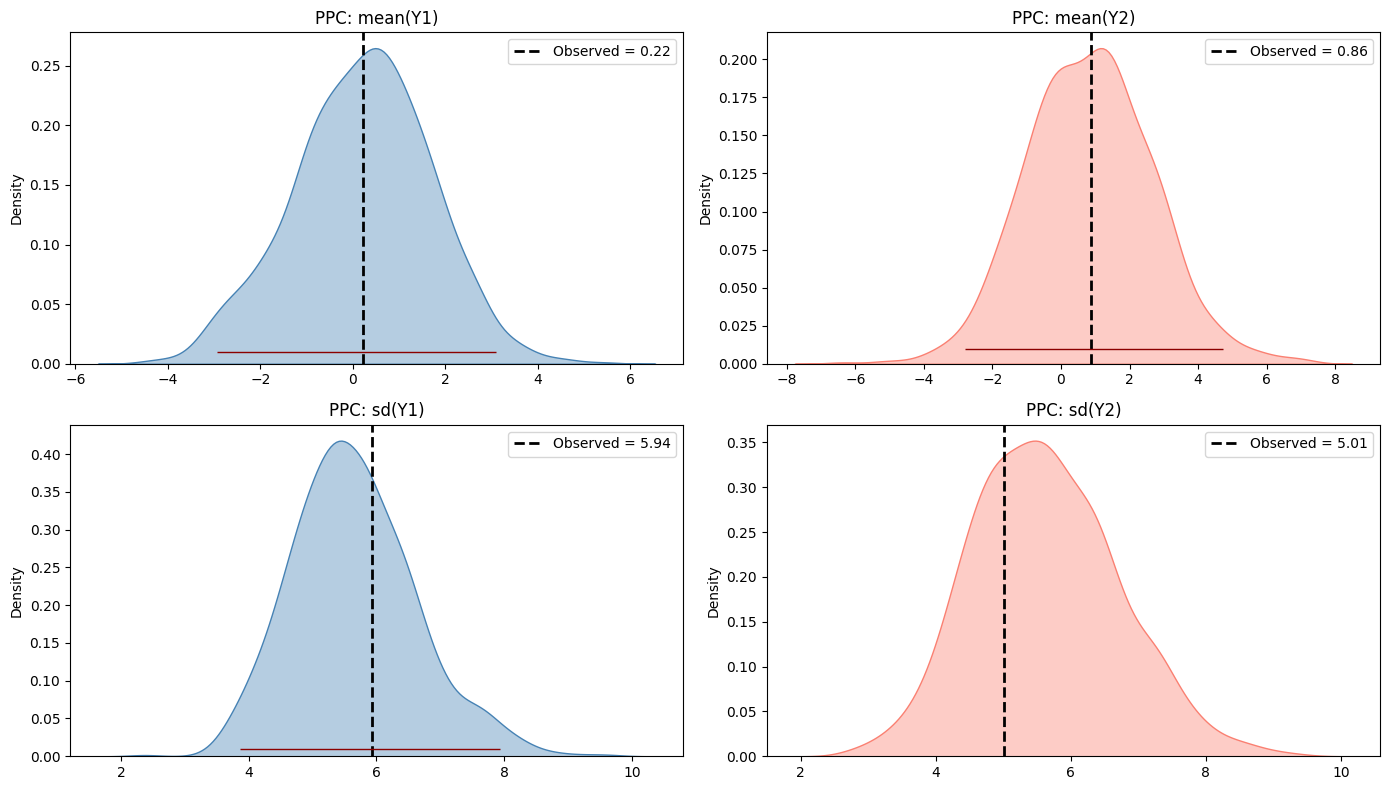

In [10]:
# Posterior Predictive Check (PPC) for the equal-SD model
rng = np.random.default_rng(1234)

S = min(1000, len(draws_equal_sd))  # 1000 개를 골라서 PPC에 사용 (너무 많으니까)
idx = rng.choice(len(draws_equal_sd), size=S, replace=False)
post = draws_equal_sd.iloc[idx]

mu1_s = post["mu1"].to_numpy()[:, None]
mu2_s = post["mu2"].to_numpy()[:, None]
sigma_s = post["sigma"].to_numpy()[:, None]

# Simulate replicated datasets from posterior draws
# 선택된 MCMC sample (mu1, mu2, sigma)로 데이터를 생성함
# 즉, 추론모델이 데이터 생성 과정을 얼마나 잘 설명하는지 평가하기 위함
# Y1_rep, Y2_rep: S x N1, S x N2
Y1_rep = rng.normal(loc=mu1_s, scale=sigma_s, size=(S, N1)) 
Y2_rep = rng.normal(loc=mu2_s, scale=sigma_s, size=(S, N2))

# Test statistics for PPC
rep_mean1 = Y1_rep.mean(axis=1)
rep_mean2 = Y2_rep.mean(axis=1)
rep_diff = rep_mean2 - rep_mean1

obs_mean1 = Y1.mean()
obs_mean2 = Y2.mean()
obs_diff = obs_mean2 - obs_mean1

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

# 평균값 비교
sns.kdeplot(rep_mean1, fill=True, color="steelblue", alpha=0.4, ax=axes[0])
axes[0].axvline(obs_mean1, color="black", linestyle="--", linewidth=2, label=f"Observed = {obs_mean1:.2f}")
axes[0].set_title("PPC: mean(Y1)")
# show the 96% interval and observed difference as text in the current figure
# 96% interval (2% ~ 98%) for the mean1 in replicated means
ci96_low, ci96_high = np.quantile(rep_mean1, [0.02, 0.98])
axes[0].hlines(
    y=0.01, xmin=ci96_low, xmax=ci96_high,
    colors="darkred", linestyles="-", linewidth=1,
#    label=f"PPC 96% interval: [{ci96_low:.2f}, {ci96_high:.2f}]  |  Observed: {obs_mean1:.2f}"
)
axes[0].legend()

sns.kdeplot(rep_mean2, fill=True, color="salmon", alpha=0.4, ax=axes[1])
axes[1].axvline(obs_mean2, color="black", linestyle="--", linewidth=2, label=f"Observed = {obs_mean2:.2f}")
axes[1].set_title("PPC: mean(Y2)")
# 96% interval (2% ~ 98%) for the mean2 in replicated means
ci96_low, ci96_high = np.quantile(rep_mean2, [0.02, 0.98])
axes[1].hlines(
    y=0.01, xmin=ci96_low, xmax=ci96_high,
    colors="darkred", linestyles="-", linewidth=1,
#    label=f"PPC 96% interval: [{ci96_low:.2f}, {ci96_high:.2f}]  |  Observed: {obs_mean2:.2f}"
)
axes[1].legend()


# 표준편차 비교
rep_sd1 = Y1_rep.std(axis=1, ddof=1)
rep_sd2 = Y2_rep.std(axis=1, ddof=1)

obs_sd1 = Y1.std(ddof=1)
obs_sd2 = Y2.std(ddof=1)

sns.kdeplot(rep_sd1, fill=True, color="steelblue", alpha=0.4, ax=axes[2])
axes[2].axvline(obs_sd1, color="black", linestyle="--", linewidth=2, label=f"Observed = {obs_sd1:.2f}")
axes[2].set_title("PPC: sd(Y1)")
ci96_low, ci96_high = np.quantile(rep_sd1, [0.02, 0.98])
axes[2].hlines(
    y=0.01, xmin=ci96_low, xmax=ci96_high,
    colors="darkred", linestyles="-", linewidth=1)
axes[2].legend()

sns.kdeplot(rep_sd2, fill=True, color="salmon", alpha=0.4, ax=axes[3])
axes[3].axvline(obs_sd2, color="black", linestyle="--", linewidth=2, label=f"Observed = {obs_sd2:.2f}")
axes[3].set_title("PPC: sd(Y2)")
axes[3].legend()

plt.tight_layout()
plt.show()

### $\mu_{1,rep}$ 의 분포가 크게 보이는 이유

지금 왼쪽 위 그림은 `mu1`의 posterior 분포가 아니라, posterior draw로 생성한 복제 데이터의 평균인 `rep_mean1 = mean(Y1_rep)`의 분포입니다.

핵심은 두 가지입니다.

1. `mu1` 자체도 표본 수가 30개라 아주 정확하게 추정되지 않습니다.
대략
$$
\mathrm{SE}(\mu_1) \approx \frac{\sigma}{\sqrt{N_1}} \approx \frac{5}{\sqrt{30}} \approx 0.9
$$
정도이므로 posterior가 어느 정도 폭을 가지는 것이 정상입니다.

2. PPC의 `rep_mean1`은 `mu1`의 불확실성에 더해, 새 데이터를 다시 생성할 때 $\sigma_{rep}$의 영향으로 생기는 표본오차까지 포함합니다.

이를 다시 설명하면 아래와 같습니다.

조건부로는

$$
Y_{1,i}^{\mathrm{rep}} \mid \mu_1,\sigma,y \sim \mathcal N(\mu_1,\sigma^2)
$$

이므로 복제표본평균은

$$
\bar Y_1^{\mathrm{rep}} \mid \mu_1,\sigma,y
\sim
\mathcal N\!\left(\mu_1,\frac{\sigma^2}{N_1}\right)
$$

입니다. 따라서

$$
E(\bar Y_1^{\mathrm{rep}}\mid \mu_1,\sigma,y)=\mu_1,\qquad
\mathrm{Var}(\bar Y_1^{\mathrm{rep}}\mid \mu_1,\sigma,y)=\frac{\sigma^2}{N_1}.
$$

이제 전체분산법칙을 쓰면

$$
\mathrm{Var}(\bar Y_1^{\mathrm{rep}}\mid y)
=
E\!\left[\mathrm{Var}(\bar Y_1^{\mathrm{rep}}\mid \mu_1,\sigma,y)\middle|y\right]
+
\mathrm{Var}\!\left(E(\bar Y_1^{\mathrm{rep}}\mid \mu_1,\sigma,y)\middle|y\right),
$$

즉

$$
\mathrm{Var}(\bar Y_1^{\mathrm{rep}}\mid y)
=
E\!\left[\frac{\sigma^2}{N_1}\middle|y\right]
+
\mathrm{Var}(\mu_1\mid y).
$$

따라서 `rep_mean1`의 분산은

1. `mu1` posterior의 불확실성  
2. 새 데이터를 다시 생성할 때의 표본오차  

가 더해진 값입니다.

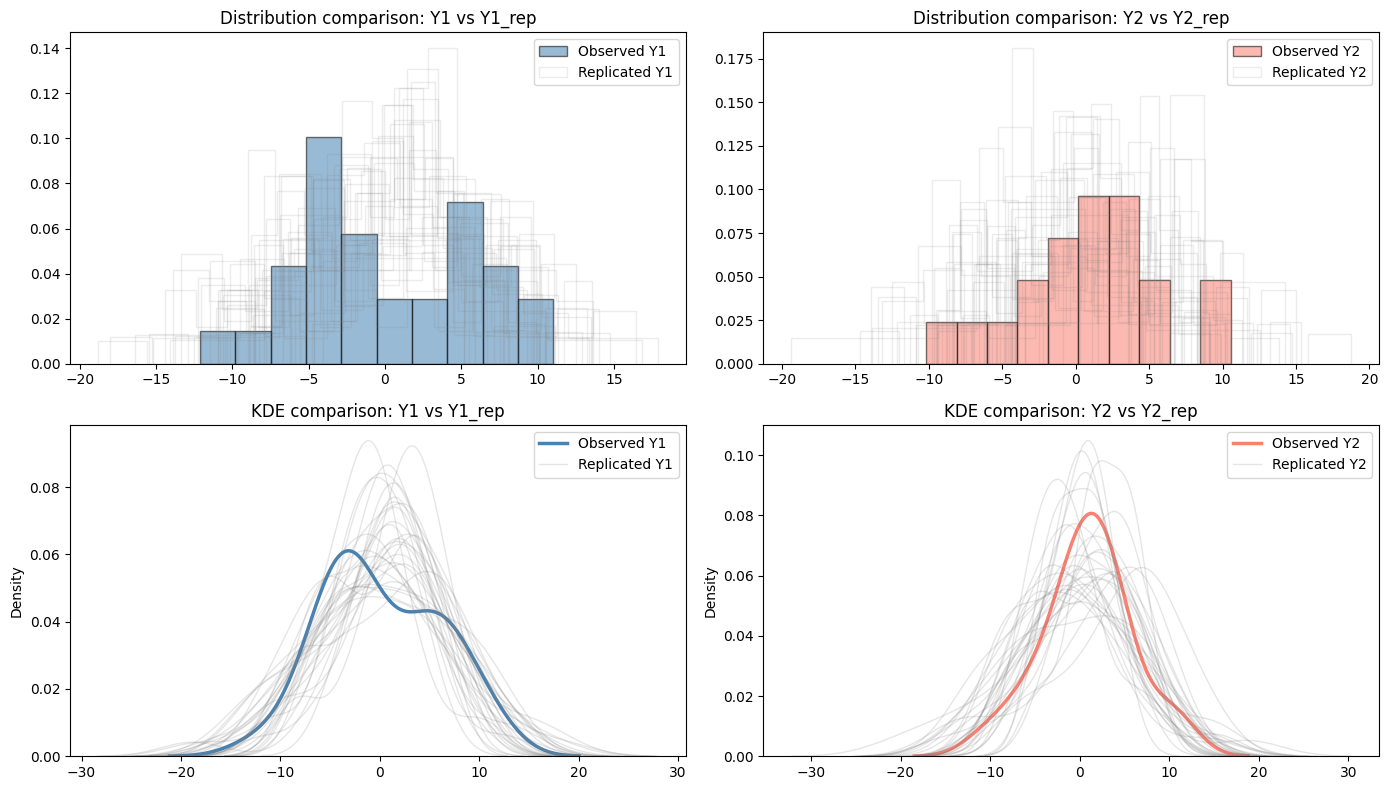

In [11]:
# Distribution comparison between observed data and replicated data
ppc_rng = np.random.default_rng(2026)

n_show = min(30, Y1_rep.shape[0], Y2_rep.shape[0])
show_idx = ppc_rng.choice(min(Y1_rep.shape[0], Y2_rep.shape[0]), size=n_show, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Y1: histogram overlay
axes[0, 0].hist(
    Y1, bins=10, density=True, alpha=0.55, color="steelblue", edgecolor="black", label="Observed Y1"
 )
for i, s in enumerate(show_idx):
    axes[0, 0].hist(
        Y1_rep[s], bins=10, density=True, histtype="step", color="gray", alpha=0.15,
        label="Replicated Y1" if i == 0 else None
    )
axes[0, 0].set_title("Distribution comparison: Y1 vs Y1_rep")
axes[0, 0].legend()

# Y2: histogram overlay
axes[0, 1].hist(
    Y2, bins=10, density=True, alpha=0.55, color="salmon", edgecolor="black", label="Observed Y2"
 )
for i, s in enumerate(show_idx):
    axes[0, 1].hist(
        Y2_rep[s], bins=10, density=True, histtype="step", color="gray", alpha=0.15,
        label="Replicated Y2" if i == 0 else None
    )
axes[0, 1].set_title("Distribution comparison: Y2 vs Y2_rep")
axes[0, 1].legend()

# Y1: KDE overlay
sns.kdeplot(Y1, ax=axes[1, 0], color="steelblue", linewidth=2.5, label="Observed Y1")
for i, s in enumerate(show_idx):
    sns.kdeplot(
        Y1_rep[s], ax=axes[1, 0], color="gray", linewidth=1, alpha=0.20,
        label="Replicated Y1" if i == 0 else None
    )
axes[1, 0].set_title("KDE comparison: Y1 vs Y1_rep")
axes[1, 0].legend()

# Y2: KDE overlay
sns.kdeplot(Y2, ax=axes[1, 1], color="salmon", linewidth=2.5, label="Observed Y2")
for i, s in enumerate(show_idx):
    sns.kdeplot(
        Y2_rep[s], ax=axes[1, 1], color="gray", linewidth=1, alpha=0.20,
        label="Replicated Y2" if i == 0 else None
    )
axes[1, 1].set_title("KDE comparison: Y2 vs Y2_rep")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

1. 관측 분포가 재생 분포들의 범위 안에 대체로 들어가면, 현재 정규모형이 데이터의 중심과 퍼짐을 무리 없이 설명한다고 볼 수 있다.
2. 반대로 관측 분포가 재생 분포들보다 더 치우치거나 꼬리가 두껍게 나타나면, normal 가정이나 등분산 가정이 충분하지 않을 가능성을 의심할 수 있다.

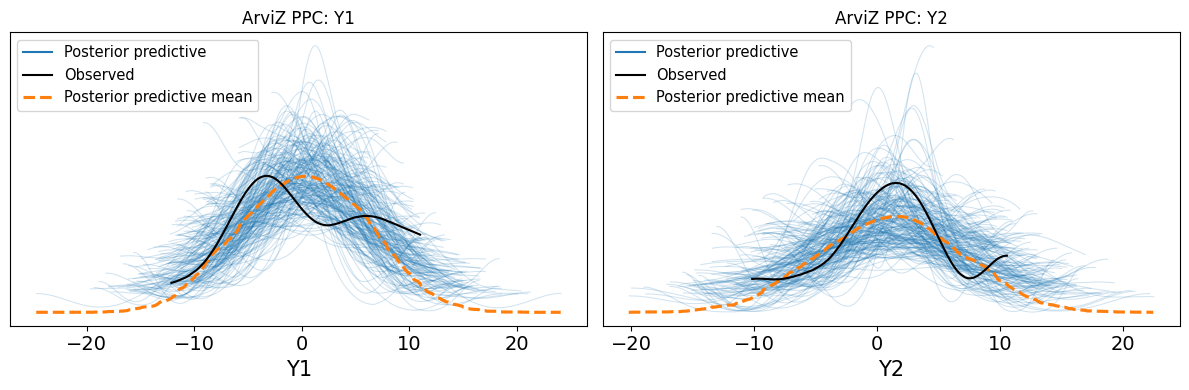

In [12]:
import arviz as az
import numpy as np

# ArviZ-based PPC for equal-SD model
rng = np.random.default_rng(2027)

mu1_s = draws_equal_sd["mu1"].to_numpy()
mu2_s = draws_equal_sd["mu2"].to_numpy()
sigma_s = draws_equal_sd["sigma"].to_numpy()
S = len(draws_equal_sd)

# Posterior predictive samples
Y1_rep_az = rng.normal(loc=mu1_s[:, None], scale=sigma_s[:, None], size=(S, N1))
Y2_rep_az = rng.normal(loc=mu2_s[:, None], scale=sigma_s[:, None], size=(S, N2))

# Build InferenceData for ArviZ
idata_ppc = az.from_dict(
    posterior={
        "mu1": mu1_s[None, :],
        "mu2": mu2_s[None, :],
        "sigma": sigma_s[None, :],
    },
    posterior_predictive={
        "Y1": Y1_rep_az[None, :, :],
        "Y2": Y2_rep_az[None, :, :],
    },
    observed_data={
        "Y1": Y1,
        "Y2": Y2,
    },
    coords={
        "Y1_obs": np.arange(N1),
        "Y2_obs": np.arange(N2),
    },
    dims={
        "Y1": ["Y1_obs"],
        "Y2": ["Y2_obs"],
    },
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
az.plot_ppc(idata_ppc, var_names=["Y1"], num_pp_samples=200, ax=axes[0])
axes[0].set_title("ArviZ PPC: Y1")
az.plot_ppc(idata_ppc, var_names=["Y2"], num_pp_samples=200, ax=axes[1])
axes[1].set_title("ArviZ PPC: Y2")
plt.tight_layout()
plt.show()

### (4) Compute Prob[mu1 < mu2] from the obtained MCMC draws using `cmdstanpy`

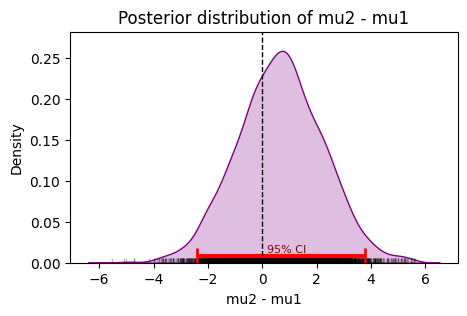

In [13]:
posterior_mu1_minus_mu2 = draws_equal_sd["mu2"] - draws_equal_sd["mu1"]
# Compute credible interval
ci_low_diff = np.quantile(posterior_mu1_minus_mu2, 0.025)
ci_high_diff = np.quantile(posterior_mu1_minus_mu2, 0.975)

plt.figure(figsize=(5, 3))
sns.kdeplot(posterior_mu1_minus_mu2, fill=True, color="purple")

# Short vertical lines (rug) at posterior draw locations of (mu2 - mu1)
sns.rugplot(
    x=posterior_mu1_minus_mu2,
    height=0.02,
    color="black",
    alpha=0.25,
    lw=0.4
)

y_ci = plt.ylim()[1] * 0.03
plt.hlines(y=y_ci, xmin=ci_low_diff, xmax=ci_high_diff, color="red", linewidth=3)
plt.plot([ci_low_diff, ci_high_diff], [y_ci, y_ci], "|", color="red", markersize=12, markeredgewidth=2)

plt.text(.2 + (ci_low_diff + ci_high_diff) / 2, y_ci * 1.5, "95% CI", fontsize=8, color="darkred", ha="center")

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("mu2 - mu1")
plt.ylabel("Density")
plt.title("Posterior distribution of mu2 - mu1")
plt.show()

In [14]:
prob_mu1_less_mu2 = (draws_equal_sd["mu1"] < draws_equal_sd["mu2"]).mean()

print(f"Prob[mu1 < mu2] = {prob_mu1_less_mu2:.4f}")

Prob[mu1 < mu2] = 0.6610


In [15]:
# Conclusion on the difference between mu1 and mu2 (equal-SD model)
p_mu1_less_mu2 = (draws_equal_sd["mu1"] < draws_equal_sd["mu2"]).mean()
mean_diff = draws_equal_sd["diff"].mean()  # mu2 - mu1
ci_low, ci_high = np.quantile(draws_equal_sd["diff"], [0.025, 0.975])

print(f"Posterior mean of (mu2 - mu1): {mean_diff:.3f}")
print(f"95% credible interval of (mu2 - mu1): [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Prob(mu1 < mu2): {p_mu1_less_mu2:.3f}")

if p_mu1_less_mu2 >= 0.95:
    print("Conclusion: Strong evidence that mu2 > mu1.")
elif p_mu1_less_mu2 <= 0.05:
    print("Conclusion: Strong evidence that mu1 > mu2.")
else:
    print("Conclusion: No strong evidence of a clear difference; mu2 tends to be larger than mu1.")

Posterior mean of (mu2 - mu1): 0.642
95% credible interval of (mu2 - mu1): [-2.394, 3.766]
Prob(mu1 < mu2): 0.661
Conclusion: No strong evidence of a clear difference; mu2 tends to be larger than mu1.


### (5) Write a model formula with the assumption that the two SDs are different, and compute Prob[mu1 < mu2]

- Assumption: $\sigma_1 \neq \sigma_2$

In [16]:
# 이 셀에 모델링과 추론 코드를 작성하세요.


---
# N1=300, N2=200
---

아래에 필요한 python 프로그램을 작성하여 실험하시오.

---
# 데이터 갯수가 다른 두 경우에 대한 추론 결과 비교 해석
---

End.